pip install prophet

In [7]:
from prophet import Prophet

阶段一：数据准备

In [10]:
import xarray as xr

# Open NetCDF file
dataset = xr.open_dataset('preprocessed_merged_dataset.nc')

# View data structure
print(dataset)

# View all variables
print(dataset.data_vars)


<xarray.Dataset> Size: 72MB
Dimensions:     (time: 27374, lat: 11, lon: 6)
Coordinates:
  * lat         (lat) float32 44B 49.48 50.42 51.36 52.3 ... 57.02 57.96 58.9
  * lon         (lon) float32 24B 352.5 353.8 355.0 356.2 357.5 358.8
  * time        (time) datetime64[ns] 219kB 2006-01-02 2006-01-03 ... 2080-12-12
Data variables:
    TREFMXAV_U  (time, lat, lon) float64 14MB ...
    FLNS        (time, lat, lon) float32 7MB ...
    FSNS        (time, lat, lon) float32 7MB ...
    PRECT       (time, lat, lon) float32 7MB ...
    PRSN        (time, lat, lon) float32 7MB ...
    QBOT        (time, lat, lon) float32 7MB ...
    TREFHT      (time, lat, lon) float32 7MB ...
    UBOT        (time, lat, lon) float32 7MB ...
    VBOT        (time, lat, lon) float32 7MB ...
Data variables:
    TREFMXAV_U  (time, lat, lon) float64 14MB ...
    FLNS        (time, lat, lon) float32 7MB ...
    FSNS        (time, lat, lon) float32 7MB ...
    PRECT       (time, lat, lon) float32 7MB ...
    PRSN    

In [12]:
#Step 2️⃣ Extract TREFHT + spatial average
trefht_mean = dataset['TREFHT'].mean(dim=['lat', 'lon'])
#Step 3️⃣ Convert to pandas DataFrame
df = trefht_mean.to_dataframe().reset_index()
#Step 4️⃣ Processing time and column names
df_prophet = df.rename(columns={'time': 'ds', 'TREFHT': 'y'})
df

,time,TREFHT
0,2006-01-02,7.633643
1,2006-01-03,8.140079
2,2006-01-04,7.396738
3,2006-01-05,7.108317
4,2006-01-06,7.409958
...,...,...
27369,2080-12-08,8.972991
27370,2080-12-09,9.551692
27371,2080-12-10,9.197808
27372,2080-12-11,8.545174


Phase 2: Model Development

In [15]:
#Step 5️⃣ Initialize the Prophet model
from prophet import Prophet
model = Prophet()

#Step 6️⃣ Train the model (historical data 2006 - 2014)
model.fit(df_prophet[df_prophet['ds'].dt.year <= 2015])

#Step 7️⃣ Create future forecasts - date forecasts 2015-2080
future = model.make_future_dataframe(periods=2080-2014, freq='Y')

#Step 8️⃣ Predict and generate results
forecast = model.predict(future)


18:00:50 - cmdstanpy - INFO - Chain [1] start processing
18:00:51 - cmdstanpy - INFO - Chain [1] done processing
/opt/anaconda3/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


Phase 3: Results Analysis

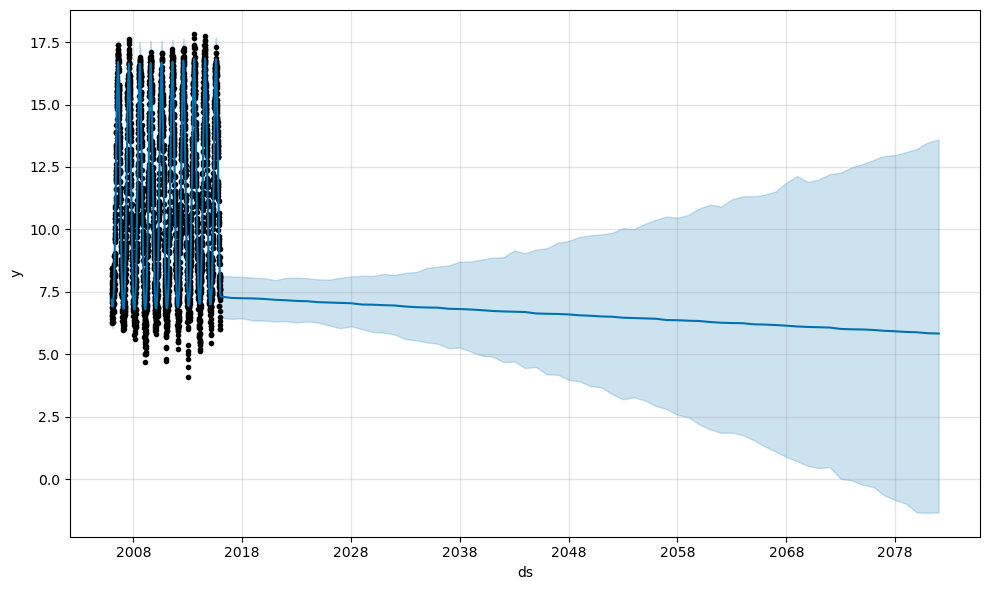

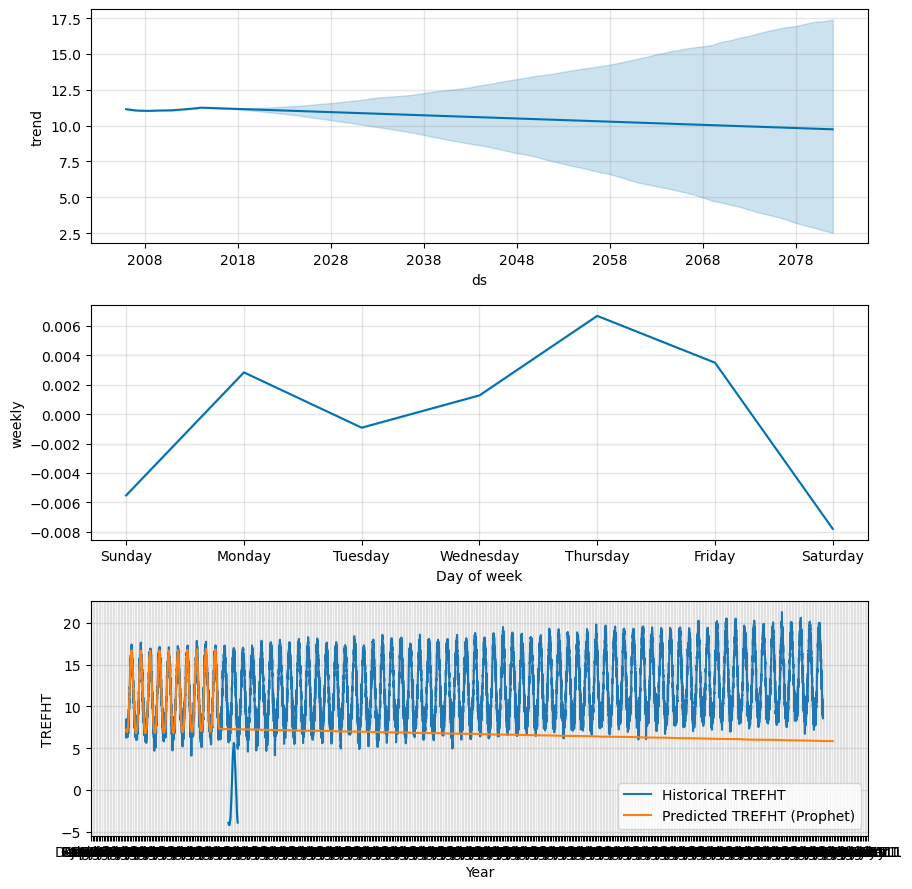

In [18]:
#Step 9️⃣ Visualize the overall trend
fig1 = model.plot(forecast)
#Step 🔟 Trend component analysis
fig2 = model.plot_components(forecast)
#Step 1️⃣ 1️⃣ Customize trend chart
import matplotlib.pyplot as plt

plt.plot(df_prophet['ds'], df_prophet['y'], label='Historical TREFHT')
plt.plot(forecast['ds'], forecast['yhat'], label='Predicted TREFHT (Prophet)')
plt.xlabel('Year')
plt.ylabel('TREFHT')
plt.legend()
plt.show()


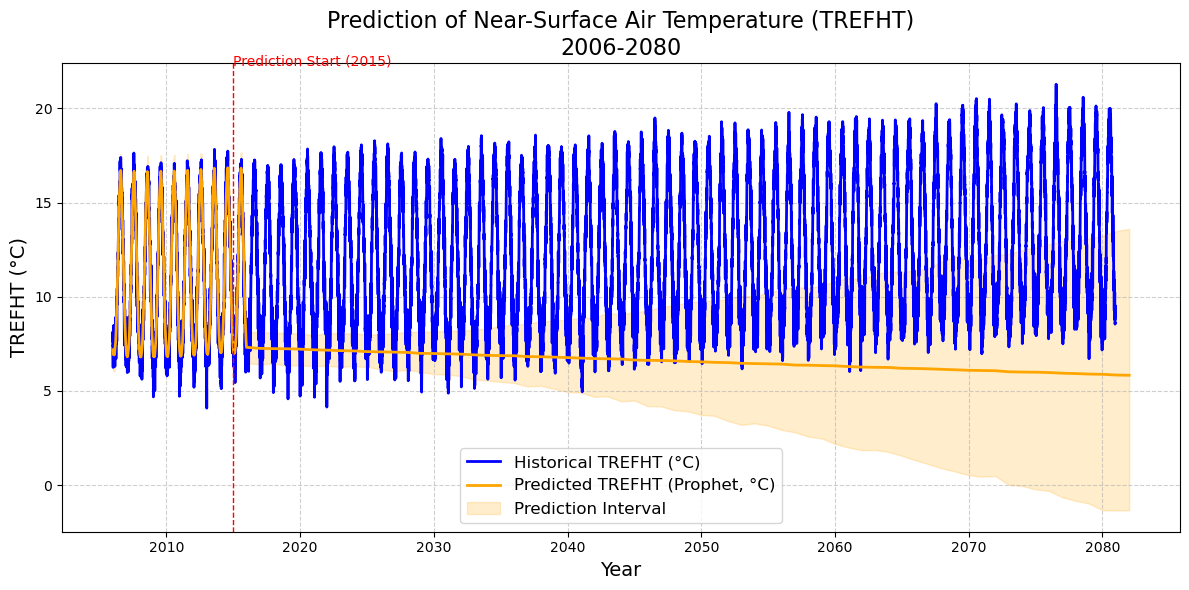

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Historical data (2006-2014)
plt.plot(df_prophet['ds'], df_prophet['y'], 
         label='Historical TREFHT (°C)', 
         color='blue', linewidth=2)

# Forecast data (2015-2080)
plt.plot(forecast['ds'], forecast['yhat'], 
         label='Predicted TREFHT (Prophet, °C)', 
         color='orange', linewidth=2)

# Confidence interval
plt.fill_between(forecast['ds'], 
                 forecast['yhat_lower'], 
                 forecast['yhat_upper'], 
                 color='orange', alpha=0.2, label='Prediction Interval')

# Prediction starting point identification line (2016)
plt.axvline(x=pd.to_datetime('2014-12-31'), color='red', linestyle='--', linewidth=1)
plt.text(pd.to_datetime('2015-01-01'), max(df_prophet['y'])+1, 
         'Prediction Start (2015)', color='red')

# Title & axis labels
plt.title('Prediction of Near-Surface Air Temperature (TREFHT)\n2006-2080', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('TREFHT (°C)', fontsize=14)

# Grid & Legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

# Optimize layout
plt.tight_layout()
plt.show()


🔵 Blue line (historical data: 2006-2014)
Shows clear periodicity (intra-year fluctuations)

Peaks and troughs are very obvious

This is the real observation data (or high-confidence data) provided by your team members

🟠 Orange line (Prophet model prediction: 2015-2080)
The trend is too stable
👉 Only captures the "trend" and does not consider the annual periodicity (seasonality disappears)
👉 Prophet will not automatically turn on yearly seasonality by default (unless you enable it)

The predicted value is almost a straight line
👉 This shows that the model judges that the temperature is rising slowly and the long-term growth trend is weak

🟡 Light orange shadow (prediction interval, uncertainty)
The uncertainty increases as time goes on

The shadow interval is from 0°C to 25°C, and the confidence interval in the next few decades is ridiculously wide
👉 This is the uncertainty problem of the Prophet model in long-term prediction

Summary of model prediction problems
Seasonal fluctuations are lost
👉 Not enabled yearly_seasonality

The trend is too stable
👉 You are using the default linear growth mode of Prophet
👉 You can consider logistic growth, or directly change the model (such as XGBoost, LSTM)

Optimized Prophet model

In [26]:
from prophet import Prophet

# Initialize the model, enable annual seasonality (manually added), multiplicative seasonality, and trend change sensitivity
model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',  # More suitable for scenarios where the temperature increases with the trend and the cycle amplitude becomes larger
    changepoint_prior_scale=0.05          # Trend changes are more sensitive
)

# Manually add annual periodicity and increase the Fourier order (more complex periodic patterns)
model.add_seasonality(
    name='yearly',
    period=365.25,
    fourier_order=20  # or 30, the larger the value, the finer the fitting of period fluctuations
)

# Train the model (using real data from 2006-2015)
train_df = df_prophet[df_prophet['ds'].dt.year <= 2015]
model.fit(train_df)


18:02:34 - cmdstanpy - INFO - Chain [1] start processing
18:02:34 - cmdstanpy - INFO - Chain [1] done processing


Generate future forecast data (2015-2080)

In [94]:
# Set the prediction time range
years_to_predict = 2080 - 2015  # 64 years

# Day granularity prediction
periods = years_to_predict * 365 

# Generate future time (including training set)
future = model.make_future_dataframe(periods=periods, freq='D')

# Make predictions
forecast = model.predict(future)

# Verify the forecast time range
print(forecast['ds'].min(), forecast['ds'].max())


2006-01-02 00:00:00 2080-12-15 00:00:00


Visualizing historical and forecast results (professional presentation)

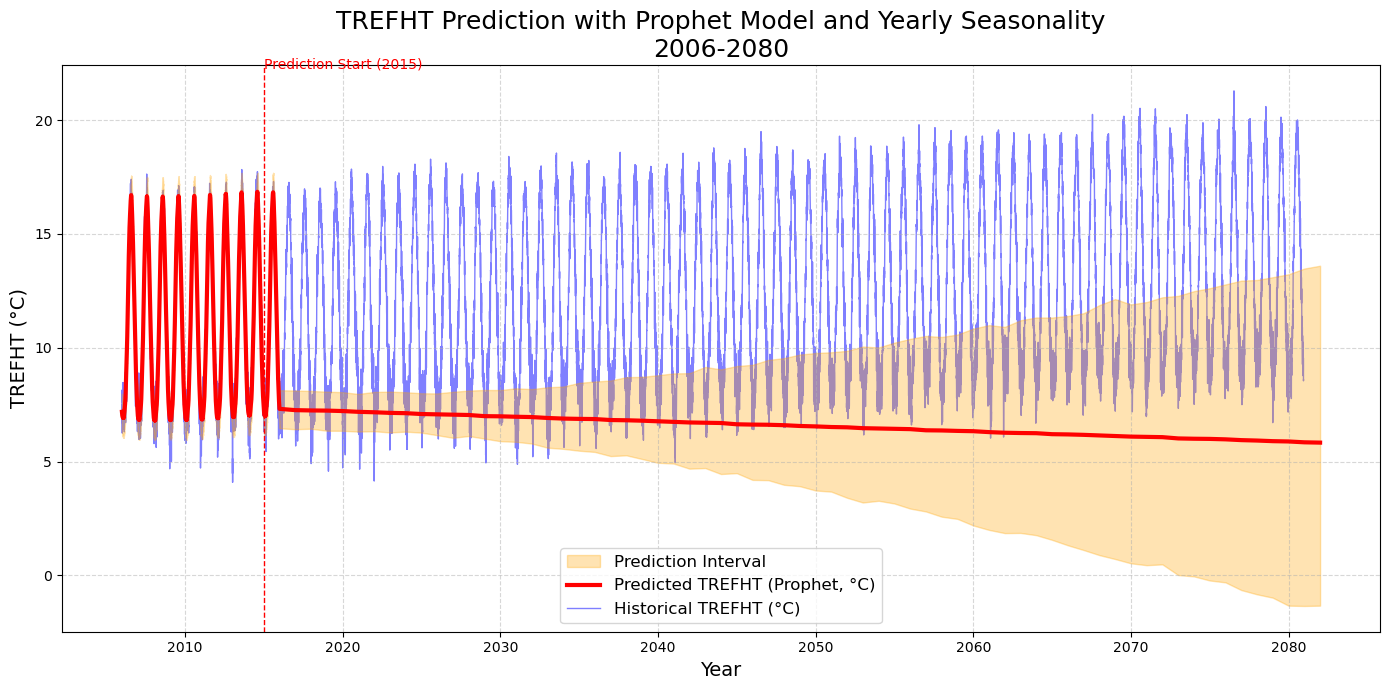

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Draw the Prediction Interval (confidence interval)
plt.fill_between(forecast['ds'],
                 forecast['yhat_lower'],
                 forecast['yhat_upper'],
                 color='orange',
                 alpha=0.3,
                 label='Prediction Interval',
                 zorder=1)

# Plotting Predicted TREFHT
plt.plot(forecast['ds'],
         forecast['yhat'],
         label='Predicted TREFHT (Prophet, °C)',
         color='red',
         linewidth=3,
         zorder=2)

# Plotting Historical TREFHT
plt.plot(df_prophet['ds'],
         df_prophet['y'],
         label='Historical TREFHT (°C)',
         color='blue',
         linewidth=1,
         alpha=0.5,
         zorder=0)

# Predict starting line
plt.axvline(x=pd.to_datetime('2014-12-31'),
            color='red', linestyle='--', linewidth=1)
plt.text(pd.to_datetime('2015-01-01'),
         df_prophet['y'].max() + 1,
         'Prediction Start (2015)',
         color='red', fontsize=10)

# Chart information
plt.title('TREFHT Prediction with Prophet Model and Yearly Seasonality\n2006-2080', fontsize=18)
plt.xlabel('Year', fontsize=14)
plt.ylabel('TREFHT (°C)', fontsize=14)

plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Verify the prediction result data

In [103]:
# View the predicted value range and trend
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))
# Confirm the time span
print(forecast['ds'].min(), forecast['ds'].max())


              ds      yhat  yhat_lower  yhat_upper
27367 2080-12-06  8.239834   -8.062600   24.579858
27368 2080-12-07  8.186231   -8.235259   24.222686
27369 2080-12-08  8.130836   -8.148980   24.400580
27370 2080-12-09  8.073168   -8.356414   24.281627
27371 2080-12-10  8.013111   -8.005593   24.204895
27372 2080-12-11  7.950962   -8.176633   24.195192
27373 2080-12-12  7.887433   -7.868041   23.862635
27374 2080-12-13  7.823601   -8.085124   23.462760
27375 2080-12-14  7.760820   -7.829218   23.446591
27376 2080-12-15  7.700590   -7.702642   22.738817
2006-01-02 00:00:00 2080-12-15 00:00:00


In [32]:
# Get the forecast data for 2017-2080
forecast_future_df = forecast[forecast['ds'] >= '2015-01-01'].copy()

# verify
print(forecast_future_df[['ds', 'yhat']].head())
print(forecast_future_df[['ds', 'yhat']].tail())


             ds      yhat
3286 2015-01-01  7.303518
3287 2015-01-02  7.275155
3288 2015-01-03  7.239771
3289 2015-01-04  7.219080
3290 2015-01-05  7.205680
             ds      yhat
3712 2077-12-31  5.921499
3713 2078-12-31  5.894667
3714 2079-12-31  5.881438
3715 2080-12-31  5.843922
3716 2081-12-31  5.830494


In [34]:
# Merge two DataFrames (aligned by ds time)
compare_df = pd.merge(
    real_future_df[['ds', 'y']],
    forecast_future_df[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on='ds',
    how='inner'
)

# Verify the merged data
print(compare_df.head())


          ds         y      yhat  yhat_lower  yhat_upper
0 2015-01-01  7.241021  7.303518    6.512266    8.149237
1 2015-01-02  6.980891  7.275155    6.377694    8.037881
2 2015-01-03  7.310610  7.239771    6.379695    8.053520
3 2015-01-04  7.168111  7.219080    6.407935    8.050596
4 2015-01-05  7.783172  7.205680    6.348347    8.036313


In [36]:
# Calculate error (MAE, RMSE)
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(compare_df['y'], compare_df['yhat'])
rmse = np.sqrt(mean_squared_error(compare_df['y'], compare_df['yhat']))

print(f"MAE（平均绝对误差）: {mae:.2f} °C")
print(f"RMSE（均方根误差）: {rmse:.2f} °C")


MAE（平均绝对误差）: 0.64 °C
RMSE（均方根误差）: 0.92 °C


In [38]:
print(compare_df)

            ds         y      yhat  yhat_lower  yhat_upper
0   2015-01-01  7.241021  7.303518    6.512266    8.149237
1   2015-01-02  6.980891  7.275155    6.377694    8.037881
2   2015-01-03  7.310610  7.239771    6.379695    8.053520
3   2015-01-04  7.168111  7.219080    6.407935    8.050596
4   2015-01-05  7.783172  7.205680    6.348347    8.036313
..         ...       ...       ...         ...         ...
424 2075-12-31  8.880668  5.974819   -0.309536   12.781077
425 2076-12-31  9.864809  5.940293   -0.647794   12.945738
426 2077-12-31  9.410761  5.921499   -0.834791   12.976319
427 2078-12-31  6.707667  5.894667   -0.982973   13.098201
428 2079-12-31  8.258852  5.881438   -1.332746   13.227935

[429 rows x 5 columns]


In [40]:
print(compare_df['y'].min())

5.440045356750488


In [42]:
print(compare_df['y'].max())

17.30228614807129
